In [1]:
from pathlib import Path
import numpy as np
import jax.numpy as jnp
from jax import random

from tensorflow_probability.substrates.jax import distributions as tfd
from tensorflow_probability.substrates.jax import bijectors as tfb
import optax

from sbijax import NPE, FMPE, CMPE
from sbijax.nn import make_maf, make_cnf, make_cm

mkdir -p failed for path /nethome/poza9/.config/matplotlib: [Errno 13] Permission denied: '/nethome/poza9'
Matplotlib created a temporary cache directory at /tmp/matplotlib-eutguhk7 because there was an issue with the default path (/nethome/poza9/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Import and prepare data

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
print(jax.devices())

[CudaDevice(id=0)]


W0420 14:31:48.884218 1385732 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0420 14:31:48.910547 1385305 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [4]:
# data_dir = Path("./time_series_data_clean_case/")
# data_dir = Path("./time_series_data_dirty_case_e0.05/")
# data_dir = Path("./time_series_data_dirty_case_e0.05_shorttraj/")
data_dir = Path("./time_series_data_dirty_case_a369_e0.05_shorttraj/")
# data_dir = Path("./time_series_data_dirty_case_a555_e0.05_shorttraj/")
# n_batches = 10
n_batches = 20 # smaller test case

In [ ]:
all_theta = []
all_x = []

for i in range(n_batches):
    theta_batch = np.load(data_dir / f"theta_batch_{i:02d}.npy")
    x_batch = np.load(data_dir / f"x_batch_fft_{i:02d}.npy")
    
    all_theta.append(theta_batch)
    all_x.append(x_batch)

theta = jnp.array(np.concatenate(all_theta, axis=0))
x = jnp.array(np.concatenate(all_x, axis=0))

print(f"Theta shape: {theta.shape}")
print(f"X shape: {x.shape}")

Theta shape: (10000, 6)
X shape: (10000, 9000)


In [ ]:
import numpy as np

theta_scaled = np.array(theta)
# log10 transform ONLY the masses (indices 0, 1, 2)
# changes range from [1e-6, 1e-3] to [-6.0, -3.0]
theta_scaled[:, 0:3] = np.log10(theta_scaled[:, 0:3])

# transform observations (x) using Z-Score
x_raw = np.array(x)
x_mean = np.mean(x_raw, axis=0)
x_std = np.std(x_raw, axis=0) + 1e-8 # epsilon to avoid zero in the denominator

x_scaled = (x_raw - x_mean) / x_std

import jax.numpy as jnp
data = {"theta": jnp.array(theta_scaled), "y": jnp.array(x_scaled)}
# data = {"theta": jnp.array(theta_scaled), "y": jnp.array(x)}

print(f"Mass scale is now: {np.min(theta_scaled[:, 0]):.2f} to {np.max(theta_scaled[:, 0]):.2f}")
print(f"X mean is: {np.mean(x_scaled):.2f}, X std is: {np.std(x_scaled):.2f}")
# print(x_mean, x_std)

Mass scale is now: -6.00 to -3.00
X mean is: 0.00, X std is: 0.94


In [21]:
print("Raw: ", x[0])
print("Scaled: ", x_scaled[0])

Raw:  [ -9.46303   -9.389501  -9.500396 ... -12.       -12.       -12.      ]
Scaled:  [ 0.07630592  0.10156997  0.056502   ... -0.01413563 -0.01414043
 -0.01414342]


### Set prior distribution

In [ ]:
n_dim_theta = theta.shape[1]
n_dim_x = x.shape[1]

def prior_fn():
    mass_dist = tfd.Independent(
        tfd.Uniform(
            low=jnp.array([-6.0, -6.0, -6.0]), 
            high=jnp.array([-3.0, -3.0, -3.0])
        ),
        reinterpreted_batch_ndims=1
    )

    a_dist = tfd.Independent(
        tfd.Uniform(
            # low=jnp.array([0.5, 5.0, 10.0]), 
            # high=jnp.array([5.0, 10.0, 15.0])
            low=jnp.array([0.5, 3.0, 6.0]), 
            high=jnp.array([3.0, 6.0, 9.0])
        ),
        reinterpreted_batch_ndims=1
    )

    blockwise_dist = tfd.Blockwise([mass_dist, a_dist])

    prior = tfd.JointDistributionNamed(
        dict(theta=blockwise_dist), 
        batch_ndims=0
    )
    
    return prior

### Train NPE Model

In [ ]:
# define NPE model
neural_network = make_maf(n_dimension=n_dim_theta, n_layers=4)
fns = (prior_fn, None)
estim = NPE(fns, neural_network, use_event_space_bijections=False)

In [24]:
# # # Define FMPE model
# neural_network = make_cnf(n_dimension=n_dim_theta, n_layers=3)
# fns = (prior_fn, None)
# estim = FMPE(fns, neural_network)

In [25]:
# # Define CMPE model
# neural_network = make_cm(n_dimension=n_dim_theta)
# fns = (prior_fn, None)
# estim = CMPE(fns, neural_network)

In [ ]:
# training the model
total_iterations = 10000

# learning rate schedule
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=int(total_iterations * 0.1),
    decay_steps=int(total_iterations * 0.9),
    end_value=1e-5
)

custom_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)
)

params, info = estim.fit(
    random.PRNGKey(0),
    data=data,
    optimizer=custom_optimizer,
    n_iter=total_iterations,
    n_early_stopping_patience=10,
    n_early_stopping_delta=0.01,
)

print("Training finished.")

  1%|          | 54/10000 [03:10<9:44:20,  3.53s/it]

Training finished.


In [27]:
# info

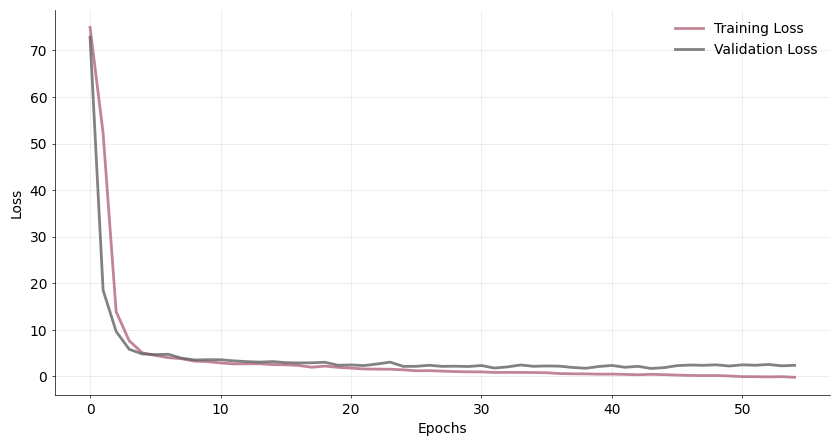

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

train_loss = info[:, 0]#.train_loss
val_loss = info[:, 1]#.validation_loss

# plot the convergence
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', alpha=0.8, linewidth=2)
plt.plot(val_loss, label='Validation Loss', alpha=0.8, linewidth=2)

plt.xlabel("Epochs")#, fontsize=12)
plt.ylabel("Loss")#, fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Test the trained model with a seen case

In [ ]:
def extract_power_spectrum(obs_data_raw):
    obs_reshaped = obs_data_raw.reshape(3, 3, -1)
    
    # if 100 timesteps, we get 51 bins
    fft_coeffs = np.fft.rfft(obs_reshaped, axis=2)
    power_spectrum = np.abs(fft_coeffs) ** 2
    
    # remove the first bin to get the wobbly bins
    wobble_power = power_spectrum[:, :, 1:] 
    log_power = np.log10(wobble_power + 1e-12)
    
    return log_power.flatten()

In [ ]:
from rebound_simulator import simulator_single, simulate_timeseries
# from extracting_power_spectrum import extract_power_spectrum

prior = prior_fn()

test_key, sample_key = random.split(random.PRNGKey(754))
true_theta_dict = prior.sample(seed=sample_key)

true_theta = true_theta_dict["theta"]
# true_theta = np.array([-3.5, -4, -6, 0.6, 7, 12])
true_theta_corrected = np.copy(true_theta)
true_theta_corrected[:3] = np.power(10, true_theta[:3])

print("Running REBOUND simulation for blind test...")
# print(true_theta)

x_obs_raw = simulate_timeseries(*np.array(true_theta_corrected), t_end=1000, num_steps=2000)
x_obs_fft = extract_power_spectrum(x_obs_raw)

print(f"Blind Test Theta shape: {true_theta.shape}")
print(f"Blind Test Compressed Observation shape: {x_obs_fft.shape}")

Running REBOUND simulation for blind test...
Blind Test Theta shape: (6,)
Blind Test Compressed Observation shape: (9000,)


In [ ]:
# scale the observation using the TRAINING mean and std
x_obs_scaled = (x_obs_fft - x_mean) / x_std

# sample the posterior
posterior_samples, _ = estim.sample_posterior(
    random.PRNGKey(99),
    params,
    observable=jnp.array(x_obs_scaled),
    # observable=jnp.array(x_obs_fft),
    n_samples=2000
)

# 4. convert the log mass back to solar/physical mass
pred_theta_scaled = jnp.mean(posterior_samples.posterior["theta"].values[0], axis=0)
pred_theta_physical = np.copy(pred_theta_scaled)
pred_theta_physical[0:3] = 10 ** pred_theta_scaled[0:3]

labels = [
    "Masses (Msun)", 
    "Semi-major Axes (AU)", 
    "Eccentricities", 
    "Inclinations (rad)", 
    "Angles: Omega, omega, f (rad)"
]
slices = [
    slice(0, 3),    # Masses
    slice(3, 6),    # a
    slice(6, 9),    # e
    slice(9, 12),   # inc
    slice(12, 21)   # Omega, omega, f
]

print("\n--- BLIND TEST: NPE Evaluation by Domain ---")
for label, slc in zip(labels, slices):
    if label == 'Masses (Msun)':
        true_slice = np.log10(true_theta_corrected[slc])
        pred_slice = np.log10(pred_theta_physical[slc])
    else:
        true_slice = true_theta_corrected[slc]
        pred_slice = pred_theta_physical[slc]
    
    mae = jnp.mean(jnp.abs(true_slice - pred_slice))
    rmse = jnp.sqrt(jnp.mean((true_slice - pred_slice)**2))
    
    print(f"\n{label}:")
    print(f"  True: {true_slice}")
    print(f"  Pred: {pred_slice}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")


--- BLIND TEST: NPE Evaluation by Domain ---

Masses (Msun):
  True: [-4.37739   -5.3278856 -3.4868073]
  Pred: [-4.1201606 -5.496065  -3.2369401]
  MAE:  0.225092
  RMSE: 0.228681

Semi-major Axes (AU):
  True: [1.9397973 3.536763  6.249183 ]
  Pred: [1.8961749 3.5992415 6.6186547]
  MAE:  0.158524
  RMSE: 0.217804

Eccentricities:
  True: []
  Pred: []
  MAE:  nan
  RMSE: nan

Inclinations (rad):
  True: []
  Pred: []
  MAE:  nan
  RMSE: nan

Angles: Omega, omega, f (rad):
  True: []
  Pred: []
  MAE:  nan
  RMSE: nan
